In [3]:
import micropip
await micropip.install(['pandas', 'matplotlib'])


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df_land_use = pd.read_csv('FAOSTAT_data_land_use.csv')
df_land_cover = pd.read_csv('FAOSTAT_data_land_cover.csv')

df_lu_area = df_land_use[df_land_use['Element'] == 'Area']
piv_lu = df_lu_area.pivot(index='Year', columns='Item', values='Value')
piv_lc = df_land_cover.pivot(index='Year', columns='Item', values='Value')

data_sheets = {
    'Forest land': piv_lu['Forest land'],
    'Planted Forest': piv_lu['Planted Forest'],
    'Woody crops': piv_lc['Woody crops'],
    'Tree-covered areas': piv_lc['Tree-covered areas']
}

titles = {
    'Forest land': 'Forest Land Area [1000 ha]',
    'Planted Forest': 'Planted Forest Area [1000 ha]',
    'Woody crops': 'Woody Crops Area [1000 ha]',
    'Tree-covered areas': 'Tree-Covered Areas [1000 ha]'
}

thresholds = {
    'Forest land': 500,
    'Planted Forest': 250,
    'Woody crops': 800,
    'Tree-covered areas': 265
}


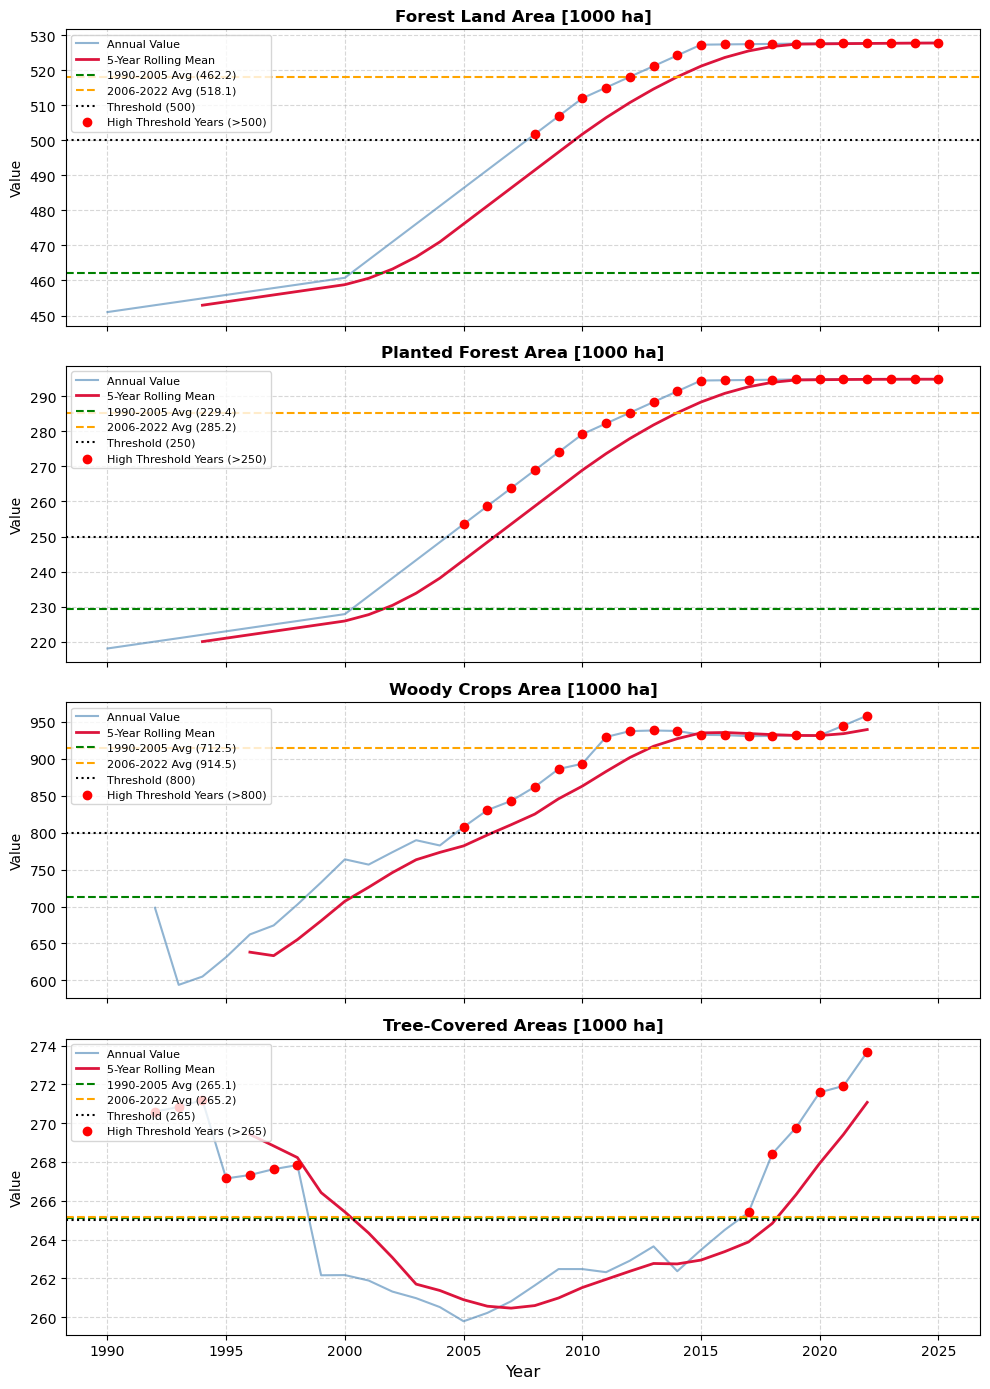

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True)

sheet_names = ['Forest land', 'Planted Forest', 'Woody crops', 'Tree-covered areas']

for ax, sheet_name_str in zip(axes, sheet_names):
    series = data_sheets[sheet_name_str].dropna()
    
    p1 = series.loc[1990:2005].mean()
    p2 = series.loc[2006:2022].mean()
    
    ax.plot(series.index, series.values, color='steelblue', alpha=0.6, label='Annual Value')
    ax.plot(series.index, series.rolling(5).mean(), color='crimson', linewidth=2, label='5-Year Rolling Mean')
    
    ax.axhline(p1, color='green', linestyle='--', label=f'1990-2005 Avg ({p1:.1f})')
    ax.axhline(p2, color='orange', linestyle='--', label=f'2006-2022 Avg ({p2:.1f})')
    
    thresh = thresholds[sheet_name_str]
    ax.axhline(thresh, color='black', linestyle=':', label=f'Threshold ({thresh})')
    
    extreme_years = series[series > thresh]
    ax.scatter(extreme_years.index, extreme_years.values, color='red', zorder=5, label=f'High Threshold Years (>{thresh})')
    
    ax.set_title(titles[sheet_name_str], fontsize=12, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left', fontsize=8)

plt.xlabel('Year', fontsize=12)
plt.tight_layout()
plt.show()


from these plots we find that the forest land and woody crops in syria show an upward trend over the last decades, particularly in planted forests and agricultural woody crops, while natural tree-covered areas show minor fluctuations around stable historical averages.

●Forest Land: Increased from 450.99k ha (1990) to 527.81k ha (2025), with the average moving from 462.21k ha (1990–2005) to 518.08k ha (2006–2022).
●Planted Forests: Expanded from 218.15k ha (1990) to over 294.81k ha (2020).
●Woody Crops: Increased from 594.05k ha (1993) to a peak of 958.21k ha (2022).
●Tree-Covered Areas: Remained relatively stable around 265k ha.